In [1]:
! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf

In [8]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from langchain_core.tools import tool

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages

from typing import Annotated, TypedDict

from langchain_core.messages import HumanMessage, BaseMessage

from langgraph.prebuilt import ToolNode, tools_condition

In [3]:
load_dotenv()

True

In [4]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [5]:
loader = PyPDFLoader("Indian_Cricket_and_IPL.pdf")
docs = loader.load()

In [6]:
len(docs)

10

In [7]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [ ]:
len(chunks)

In [9]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
)
vector_store = FAISS.from_documents(chunks, embeddings)

In [10]:
vector_store

In [11]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [12]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [13]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [14]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [15]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [16]:
tool_node = ToolNode(tools)

In [17]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

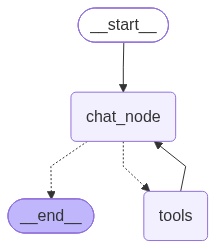

In [18]:
chatbot

In [19]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain the history of BCCI"
                )
            )
        ]
    }
)

In [20]:
print(result['messages'][-1].content)

[{'type': 'text', 'text': "The Board of Control for Cricket in India (BCCI) was founded in 1928 and is the governing body for cricket in the country, headquartered in Mumbai.\n\nIts key functions include:\n*   Organizing international matches hosted in India.\n*   Managing domestic competitions.\n*   Overseeing the Indian Premier League (IPL).\n*   Selecting and managing the men's, women's, and age-group national cricket teams.\n*   Conducting domestic tournaments like the Ranji Trophy, Vijay Hazare Trophy, and the Women's Premier League (WPL), which was launched in 2023.\n*   Representing India within the International Cricket Council (ICC).\n*   Developing cricketing infrastructure and grassroots programs across the country.\n\nThe BCCI is considered the wealthiest cricket board globally, primarily due to the substantial media rights and sponsorship value generated by the IPL and India's vast cricket-following population. This financial strength gives the BCCI significant influence o